In [1]:
import pandas as pd
import csv
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

#### Definition of the size of each temporal intervals (100 ms)

In [2]:
STEP_TIME = 100

# Number of spike metric (Spikes per timestamps)

To evaluate the resulting spikes from each attack instant, the authors defined two functions: one to calculate the number of spikes and another to plot the results for each attack instant as well as the spontaneous activity.

In [32]:
def number_spikes(df_stimulus):
# First, the function rounds the timestamp values of the given dataframe and divides them by 100 ms, the size previously mentioned, 
# to create the new column "position". This column represents the timestamps corresponding to their temporal intervals.
    df_stimulus["timestamps"] = df_stimulus["timestamps"].round(1)
    df_stimulus['position'] = 0
    df_stimulus['position'] = df_stimulus['timestamps']/STEP_TIME
    df_stimulus['position'] = df_stimulus['position'].apply(lambda x: np.floor(x))
    df_stimulus['position'] = df_stimulus['position'].astype(int)

# Secondly, it creates a new column that indicates which attack is executed and the attack instant.
    if "FLO" in df_stimulus["attack"].values:

        if df_stimulus['stimulus'].str.contains("Gratings", case=False).any():
            if (450 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO gray stimulus"

            elif (600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO beginning gratings"

            elif (1600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during gratings"

        elif df_stimulus['stimulus'].str.contains("Movie", case=False).any():
            if (450 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO gray stimulus"

            elif (550 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO beginning movie"

            elif (1600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during movie"

                
        elif df_stimulus['stimulus'].str.contains("flash", case=False).any():
            if (625 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during ON"

            elif (1300 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO between ON/OFF"

            elif (1875 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during OFF" 
                    
    elif "JAM" in df_stimulus["attack"].values:
        if df_stimulus['stimulus'].str.contains("Gratings", case=False).any():
            if (400 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM gray stimulus"

            elif (600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM beginning gratings"

            elif (1600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during gratings"

        elif df_stimulus['stimulus'].str.contains("Movie", case=False).any():
            if (400 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM gray stimulus"

            elif (500 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM beginning movie"

            elif (1600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during movie"
                
        elif df_stimulus['stimulus'].str.contains("Flash", case=False).any():
            if (600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during ON"

            elif (1800 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during OFF"
            
            elif (1300 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM between ON/OFF"

    elif "Spontaneous" in df_stimulus["attack"].values:
          df_stimulus["attack"] = "Spontaneous"

# Finally, the function counts the number of neurons per timestamps and position. After that, the resulting dataframe is returned.  
    df_stimulus = pd.DataFrame(df_stimulus.groupby(["attack","n_exec","timestamps","position"])["neuron_ids"].count())
    df_stimulus.reset_index(inplace=True)
    return df_stimulus

def combination_num_spikes(df_stimulus,df_stimulus_2,df_stimulus_3,df_spontaneous, stimulus):
    # Once the function "number_spikes" returns the new count of each attack instant and spontaneous spikes, this second function
    # join the four dataframes to calculate the number of spikes per position. 
    df_combination = pd.concat([df_stimulus,df_stimulus_2,df_stimulus_3,df_spontaneous])
    df_combination['n_spikes'] = df_combination['neuron_ids']
    df_combination['position'] += 1

    # Based on the count of the number of neurons per timestamp and position, it adds the count according to the position.  
    df_combination = pd.DataFrame(df_combination.groupby(["attack","n_exec","position"])["n_spikes"].sum())
    df_combination.reset_index(inplace=True)

    df_combination = df_combination[df_combination['position'] != 31]
    
    # The results obtained are plotted in the next way:
    plt.rcParams.update({'font.family': 'monospace'})
    sns.set(style="whitegrid",font_scale=2.5, rc={'figure.figsize':(40,20)})
    plt.rcParams['axes.edgecolor'] = "black" #set the value globally
    
    label_size = 70
    ticks_size = 60
    legend_size = 45
    line_size = 60

    fig, ax = plt.subplots(figsize=(40,20))

    # Flash plot
    if "flash" in stimulus:
        # FLO
        if df_stimulus['attack'].str.contains("FLO", case=False).any():
            sns.pointplot(x="position", y="n_spikes", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO during ON','FLO between ON/OFF','FLO during OFF','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax, dodge=True)
            ax.axvspan(5.8, 6.2, color="grey", alpha=0.4)
            ax.axvspan(12.8, 13.2, color="grey", alpha=0.4)
            ax.axvspan(17.8, 18.2, color="grey", alpha=0.4)

            ymin, ymax = ax.get_ylim()
            ymin_extended = ymin - 0.1 * (ymax - ymin)  
            ymax_extended = ymax + 100 * (ymax - ymin)  

            ax.vlines([5.8, 6.2], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([12.8, 13.2], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([17.8, 18.2], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)

        # JAM
        else:
            sns.pointplot(x="position", y="n_spikes", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['JAM during ON','JAM between ON/OFF','JAM during OFF','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax, dodge=True, zorder=3)
            ax.axvspan(5.5, 6.5, color="grey", alpha=0.2)
            ax.axvspan(12.5, 13.5, color="grey", alpha=0.2)
            ax.axvspan(17.5, 18.5, color="grey", alpha=0.2)

            ymin, ymax = ax.get_ylim()
            ymin_extended = ymin - 0.1 * (ymax - ymin)  
            ymax_extended = ymax + 100 * (ymax - ymin)  

            ax.vlines([5.5, 6.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([12.5, 13.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([17.5, 18.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)

    # Drifting gratings plot
    elif "gratings" in stimulus:
        # FLO
        if df_stimulus['attack'].str.contains("FLO", case=False).any():
            sns.pointplot(x="position", y="n_spikes", data= df_combination, palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning gratings','FLO during gratings','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax, dodge=True)
            ax.axvspan(3.8, 4.2, color="grey", alpha=0.4)
            ax.axvspan(5.8, 6.2, color="grey", alpha=0.4)
            ax.axvspan(15.8, 16.2, color="grey", alpha=0.4)

            ymin, ymax = ax.get_ylim()
            ymin_extended = ymin - 0.1 * (ymax - ymin)  
            ymax_extended = ymax + 100 * (ymax - ymin)  

            ax.vlines([3.8, 4.2], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([5.8, 6.2], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([15.8, 16.2], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        # JAM
        else:
            sns.pointplot(x="position", y="n_spikes", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning gratings','JAM during gratings','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax, dodge=True, zorder=3)
            ax.axvspan(3.5, 4.5, color="grey", alpha=0.2)
            ax.axvspan(5.5, 6.5, color="grey", alpha=0.2)
            ax.axvspan(15.5, 16.5, color="grey", alpha=0.2)

            ymin, ymax = ax.get_ylim()
            ymin_extended = ymin - 0.1 * (ymax - ymin)  
            ymax_extended = ymax + 100 * (ymax - ymin)  

            ax.vlines([3.5, 4.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([5.5, 6.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([15.5, 16.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)

    # Movie plot
    elif "movie" in stimulus:
        # FLO
        if df_stimulus['attack'].str.contains("FLO", case=False).any():
            sns.pointplot(x="position", y="n_spikes", data= df_combination, palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning movie','FLO during movie','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax, dodge=True)
            ax.axvspan(3.8, 4.2, color="grey", alpha=0.4)
            ax.axvspan(4.8, 5.2, color="grey", alpha=0.4)
            ax.axvspan(15.8, 16.2, color="grey", alpha=0.4)

            ymin, ymax = ax.get_ylim()
            ymin_extended = ymin - 0.1 * (ymax - ymin)  
            ymax_extended = ymax + 100 * (ymax - ymin)  

            ax.vlines([3.8, 4.2], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([4.8, 5.2], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([15.8, 16.2], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        # JAM
        else:
            sns.pointplot(x="position", y="n_spikes", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning movie','JAM during movie','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax, dodge=True, zorder=3)
            ax.axvspan(3.5, 4.5, color="grey", alpha=0.2)
            ax.axvspan(4.5, 5.5, color="grey", alpha=0.2)
            ax.axvspan(15.5, 16.5, color="grey", alpha=0.2)

            ymin, ymax = ax.get_ylim()
            ymin_extended = ymin - 0.1 * (ymax - ymin) 
            ymax_extended = ymax + 100 * (ymax - ymin)  

            ax.vlines([3.5, 4.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([4.5, 5.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            ax.vlines([15.5, 16.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)


    # Axis parameters 
    ax.set_xlabel("Time interval", fontsize=label_size, fontweight="bold")
    ax.set_ylabel("Number of spikes", fontsize=label_size, fontweight="bold")
    ax.tick_params(labelsize=ticks_size)
    ax.set_ylim(0, 180000, 20000)
    ax.set_xlim(-1, 30, 1)     
    
    leg= ax.legend(loc='upper right', fancybox=True, shadow=True, ncol=1, frameon='True',fontsize=legend_size)  
    leg.get_frame().set_edgecolor('black')

    plt.xticks(rotation=70)
    ax.xaxis.grid(True)

    # The plot created is saved as a PDF file to improve the visualization. 
    plt.savefig("./number_of_spikes_flash_FLO_halfnum_625_1300_1875ms.pdf", bbox_inches='tight')

 

# Use case of number of spikes

In [4]:
# Attack instants of flash effect.
df_stimulus = pd.read_csv("./output_FLO_625ms_halfnum_Vth_flash_trial_9_BKG_trial_99_10exec/spikes.csv", delimiter=";") 
df_stimulus_2 = pd.read_csv("./output_FLO_1300ms_halfnum_Vth_flash_trial_9_BKG_trial_99_10exec/spikes.csv", delimiter=";")
df_stimulus_3 = pd.read_csv("./output_FLO_1875ms_halfnum_Vth_flash_trial_9_BKG_trial_99_10exec/spikes.csv", delimiter=";")
# Normal activity using flash effect as input.
df_spontaneous = pd.read_csv("./output_flash_h5_trial_9_BKG_trial_99/spikes.csv", delimiter=";")

df_stimulus = number_spikes(df_stimulus)
df_stimulus_2 = number_spikes(df_stimulus_2)
df_stimulus_3 = number_spikes(df_stimulus_3)
df_spontaneous = number_spikes(df_spontaneous)                  

/tmp/ipykernel_27459/3509377829.py:161: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(x="position", y="n_spikes", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO during ON','FLO between ON/OFF','FLO during OFF','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax, dodge=True)
/tmp/ipykernel_27459/3509377829.py:161: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 10.0}` instead.

  sns.pointplot(x="position", y="n_spikes", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO during ON','FLO between ON/OFF','FLO during OFF','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax, dodge=True)
/tmp/ipykernel_27459/3509377

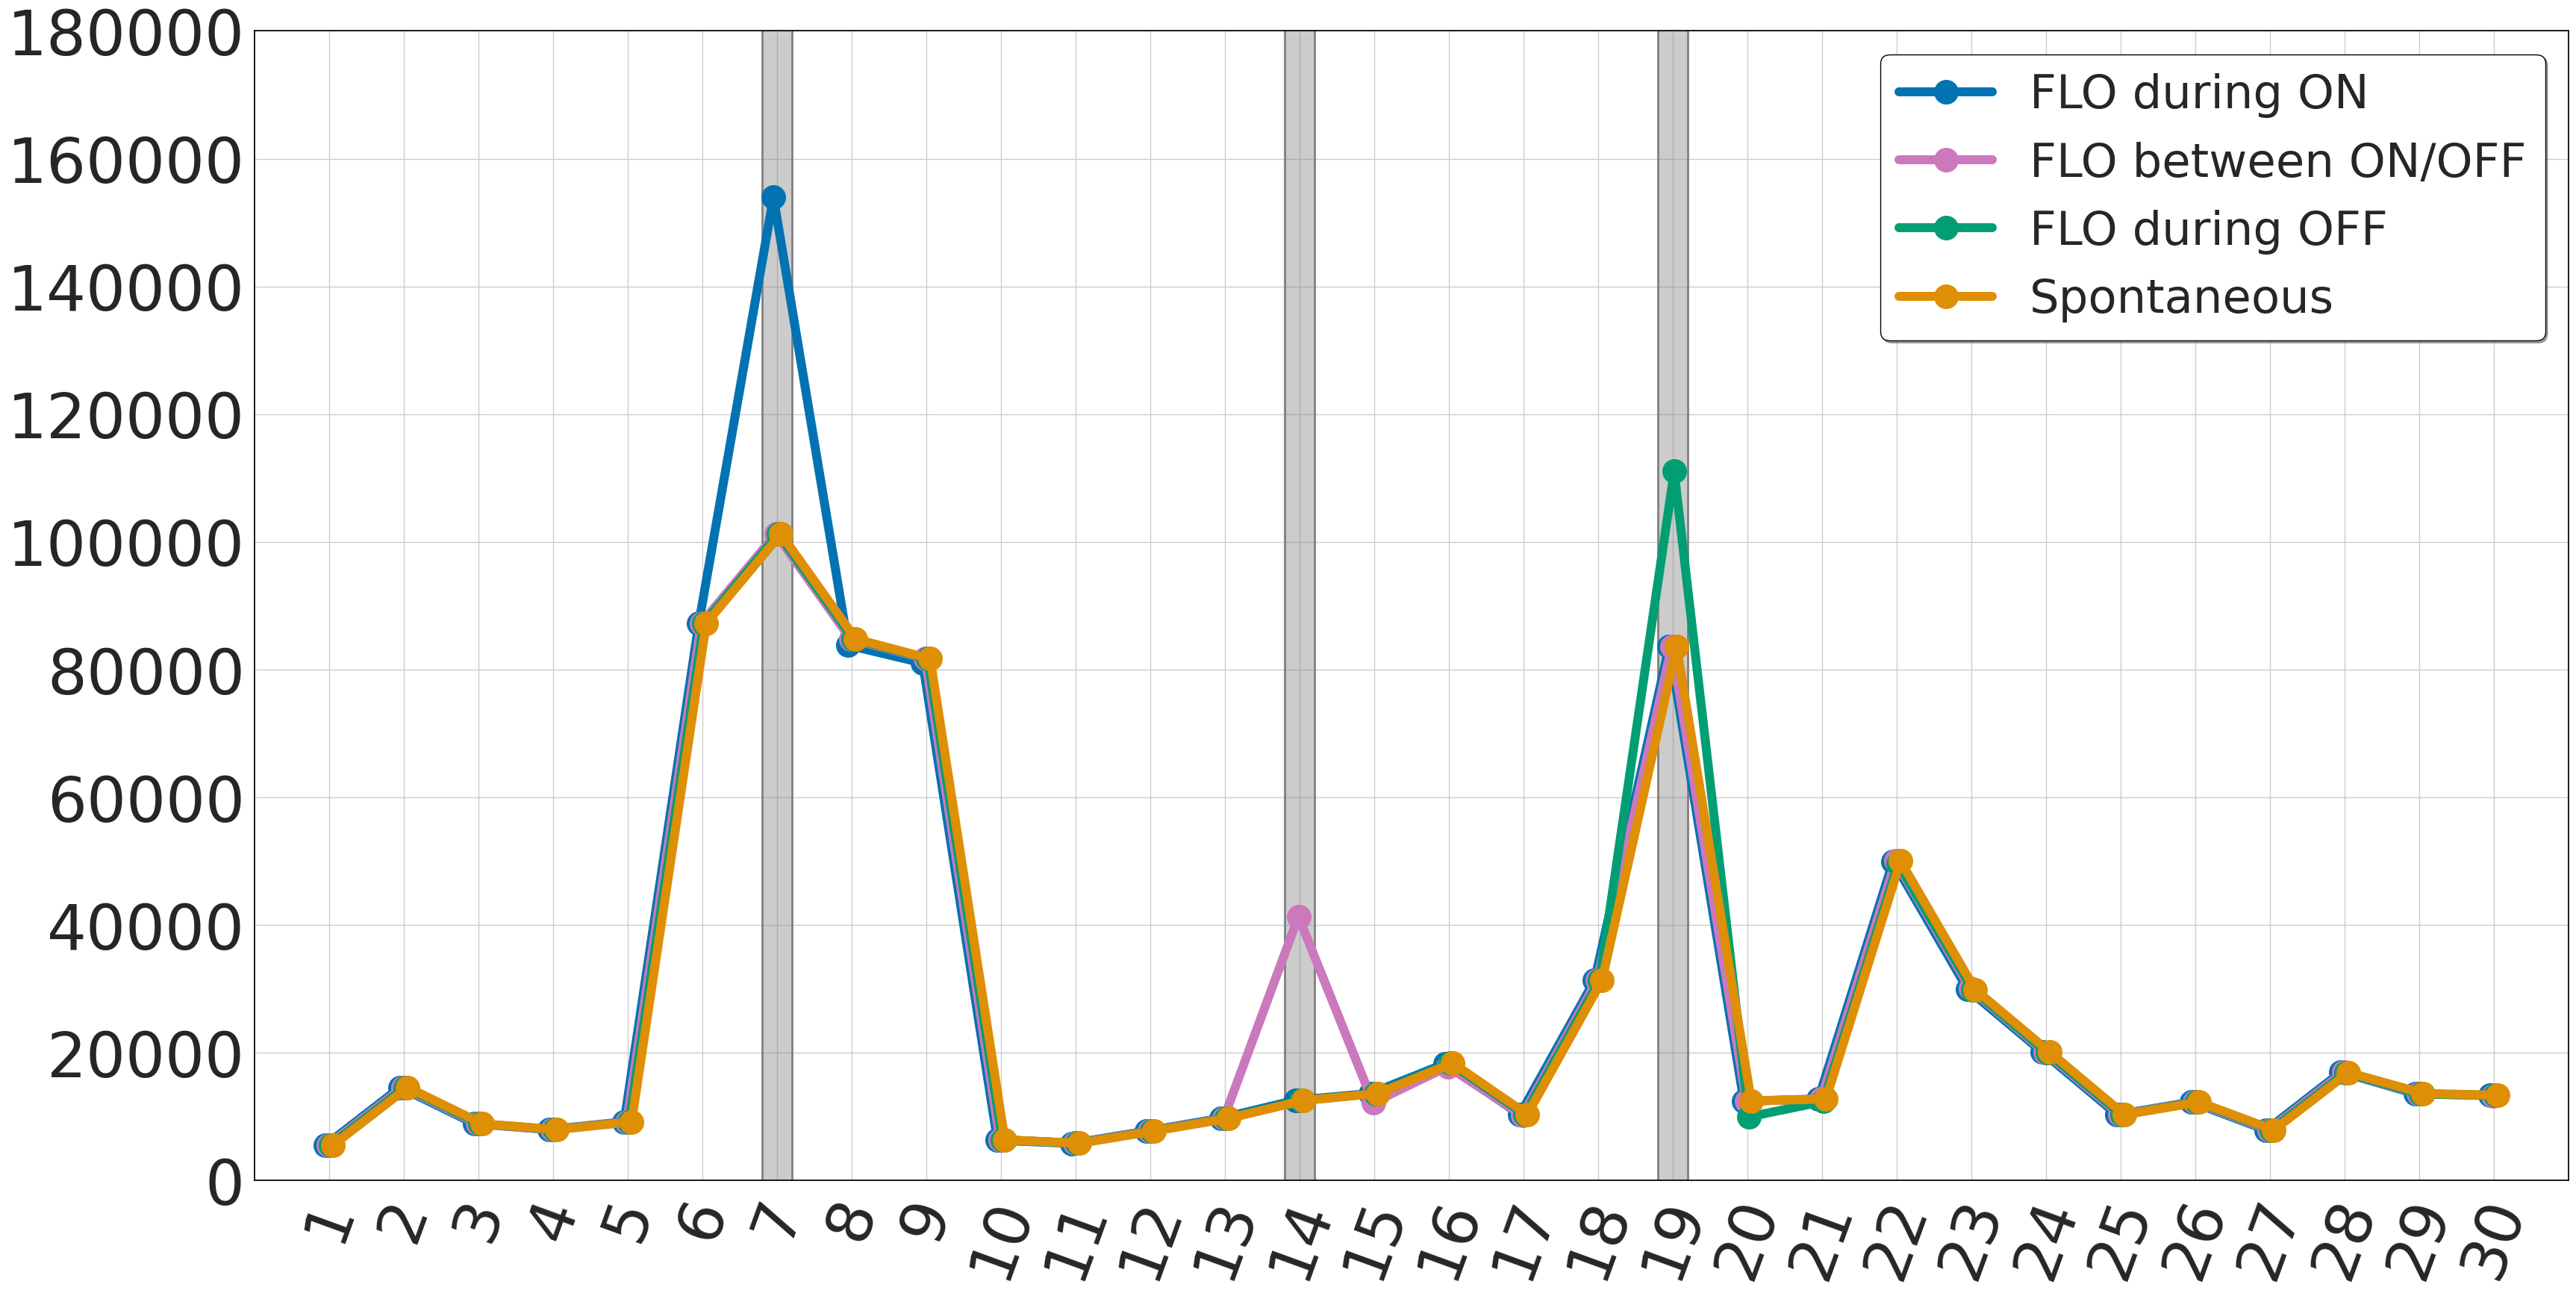

In [33]:
combination_num_spikes(df_stimulus,df_stimulus_2,df_stimulus_3,df_spontaneous,"flash")

# Percentage of shifts metric (Delay of spikes in time compared to spontaneous behavior)

As the previous metric, the authors create two functions. The first function is responsible for calculating the delay of each attack instant compared to the spontaneous activity per time interval. In contrast, the second function handles the visual representation of the results. 

In [3]:
def percentage_shift_per_instant(df_stimulus, df_spontaneous):
    # First, the function rounds the timestamp values of a specific attack instant and spontaneous activity dataframes and divides them by 100 ms, the size previously mentioned, 
    # to create the new column "position". This column represents the timestamps corresponding to their temporal intervals.
    df_stimulus['position'] = 0
    df_stimulus['position'] = df_stimulus['timestamps']/STEP_TIME
    df_stimulus['position'] = df_stimulus['position'].apply(lambda x: np.floor(x))
    df_stimulus['position'] = df_stimulus['position'].astype(int)
    df_stimulus['position'] += 1

    df_spontaneous['position'] = 0
    df_spontaneous['position'] = df_spontaneous['timestamps']/STEP_TIME
    df_spontaneous['position'] = df_spontaneous['position'].apply(lambda x: np.floor(x))
    df_spontaneous['position'] = df_spontaneous['position'].astype(int)
    df_spontaneous['position'] += 1

    # Secondly, it creates a new column that indicates which attack is executed and the attack instant.
    if "FLO" in df_stimulus["attack"].values:

        if df_stimulus['stimulus'].str.contains("Gratings", case=False).any():
            if (450 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO gray stimulus"

            elif (600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO beginning gratings"

            elif (1600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during gratings"

        elif df_stimulus['stimulus'].str.contains("Movie", case=False).any():
            if (450 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO gray stimulus"

            elif (550 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO beginning movie"

            elif (1600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during movie"
                
        elif df_stimulus['stimulus'].str.contains("Flash", case=False).any():

            if (625 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during ON"

            elif (1300 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO between ON/OFF"

            elif (1875 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during OFF" 
                    
    elif "JAM" in df_stimulus["attack"].values:
        
        if df_stimulus['stimulus'].str.contains("Gratings", case=False).any():
            if (400 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM gray stimulus"

            elif (600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM beginning gratings"

            elif (1600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during gratings"

        elif df_stimulus['stimulus'].str.contains("Movie", case=False).any():
            if (400 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM gray stimulus"

            elif (500 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM beginning movie"

            elif (1600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during movie"
                
        elif df_stimulus['stimulus'].str.contains("Flash", case=False).any():
            if (600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during ON"

            elif (1300 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM between ON/OFF"

            elif (1800 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during OFF"
    
    # Thirdly, the function follows the next steps to obtain the percentage of spikes that do not coincide:

    # Merge the stimulus and spontaneous dataframes on the columns 'timestamps', 'neuron_ids', and 'position'.
    # This merge includes all rows from the stimulus dataframe and only matching rows from the spontaneous dataframe.
    # Rows with no match in the spontaneous dataframe have their values replaced with 0.
    join_attack_shifts = pd.merge(df_stimulus, df_spontaneous, how='left', left_on=["timestamps", "neuron_ids", "position"], right_on=["timestamps", "neuron_ids", "position"])
    join_attack_shifts = join_attack_shifts.fillna(0)

    # Filter the rows where the column 'attack_y' is 0, which indicates spikes that do not coincide with the spontaneous data.
    filtered_shifts = join_attack_shifts[join_attack_shifts['attack_y'] == 0]

    # Group the filtered data by 'attack_x', 'n_exec_x', and 'position', counting the number of unique 'neuron_ids' per group to obtain the number of shifts of the attack.
    n_shifts_attack = pd.DataFrame(filtered_shifts.groupby(["attack_x", "n_exec_x", "position"])["neuron_ids"].count())
    n_shifts_attack.reset_index(inplace=True)

    # Group the stimulus data by 'n_exec' and 'position', counting the number of unique 'neuron_ids' per group to obtain the number of spikes of the attack.
    attack_nSpikes = pd.DataFrame(df_stimulus.groupby(["n_exec", "position"])["neuron_ids"].count())
    attack_nSpikes.reset_index(inplace=True)

    # Rename columns in both dataframes to make the subsequent merge operation more intuitive.
    n_shifts_attack.rename(columns={'neuron_ids': 'n_shifts_count'}, inplace=True)
    attack_nSpikes.rename(columns={'neuron_ids': 'n_spikes_count'}, inplace=True)

    # Merge the two dataframes based on 'n_exec' and 'position' to compute the percentage of non-coinciding spikes per position.
    percent_shifts_attack = pd.merge(n_shifts_attack, attack_nSpikes, left_on=["n_exec_x", "position"], right_on=["n_exec", "position"], how='left')

    # Calculate the percentage of spikes that do not coincide.
    # This is computed as the count of shifts divided by the total number of spikes, multiplied by 100.
    percent_shifts_attack['percent_shifts'] = round((percent_shifts_attack['n_shifts_count'] / percent_shifts_attack['n_spikes_count']) * 100, 2)

    # Select only the necessary columns for further processing.
    percent_shifts_attack = percent_shifts_attack[['attack_x', 'n_exec_x', 'position', 'percent_shifts']]

    # Generate all possible combinations of 'attack', 'n_exec', and 'position' for a complete result set.   
    all_n_exec = df_stimulus['n_exec'].unique()
    all_attack = df_stimulus['attack'].unique()
    all_positions = range(1, 31)
    all_combinations = pd.MultiIndex.from_product([all_attack, all_n_exec, all_positions], names=['attack','n_exec', 'position']).to_frame(index=False)

    # Merge the computed percentages with the complete list of combinations to ensure all cases are represented.
    percent_shifts_attack = pd.merge(all_combinations, percent_shifts_attack, left_on=['attack','n_exec', 'position'], right_on=['attack_x','n_exec_x', 'position'], how='left')

    # Replace NaN values in the percentage column with 0 to handle missing data.
    percent_shifts_attack = percent_shifts_attack.fillna(0)

    # Select the final required columns and reset the index to produce the result dataframe.
    result_dataframe = percent_shifts_attack[['attack','n_exec', 'position', 'percent_shifts']]
    result_dataframe.reset_index(drop=True, inplace=True)

    # Replace percentages of 0.00 with NaN for clarity in the output and reset the index again.
    result_dataframe.loc[:, 'percent_shifts'] = result_dataframe['percent_shifts'].replace(0.00, np.nan)
    result_dataframe.reset_index(drop=True, inplace=True)

    return result_dataframe
    
def combination_percentage_shift_per_instant(df_stimulus,df_stimulus_2,df_stimulus_3, stimulus):
    # Once the function "percentage_shift_per_instant" returns the dataframes with the shifts percentage, this second function
    # joins the three dataframes to represent the results visually. 
    df_combination = pd.concat([df_stimulus,df_stimulus_2,df_stimulus_3])
    df_combination.reset_index(drop=True, inplace=True)

    # The results obtained are plotted in the next way:
    plt.rcParams.update({'font.family': 'monospace'})
    sns.set(style="whitegrid",font_scale=2.5, rc={'figure.figsize':(40,20)})
    plt.rcParams['axes.edgecolor'] = "black" #set the value globally
    label_size = 70
    ticks_size = 60
    legend_size = 35
    line_size = 60

    fig, ax = plt.subplots(figsize=(40,21))

    # Flash plot
    if "flash" in stimulus:
        #FLO
        if df_stimulus['attack'].str.contains("FLO", case=False).any():
            sns.barplot(x="position", y="percent_shifts", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['FLO during ON','FLO between ON/OFF','FLO during OFF'],errorbar="sd", errwidth=10.0,  ax=ax, width=0.9)
            ax.axvspan(5.5, 6.5, color="grey", alpha=0.4)
            ax.axvspan(12.5, 13.5, color="grey", alpha=0.4)
            ax.axvspan(17.5, 18.5, color="grey", alpha=0.4)
        #JAM
        else:
            sns.barplot(x="position", y="percent_shifts", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM during ON','JAM between ON/OFF','JAM during OFF'], errorbar="sd", errwidth=10.0, ax=ax, width=0.9)
            ax.axvspan(5.5, 6.5, color="grey", alpha=0.4)
            ax.axvspan(12.5, 13.5, color="grey", alpha=0.4)
            ax.axvspan(17.5, 18.5, color="grey", alpha=0.4)

        ymin, ymax = ax.get_ylim()
        ymin_extended = ymin - 0.1 * (ymax - ymin)  
        ymax_extended = ymax + 100 * (ymax - ymin)  

        ax.vlines([5.5, 6.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        ax.vlines([12.5, 13.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        ax.vlines([17.5, 18.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
            
    # Drifting gratings plot
    elif "gratings" in stimulus:
        #FLO
        if df_stimulus['attack'].str.contains("FLO", case=False).any():
            sns.barplot(x="position", y="percent_shifts", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning gratings','FLO during gratings'], errorbar="sd", errwidth=10.0, ax=ax, width=0.9)
            ax.axvspan(3.5, 4.5, color="grey", alpha=0.4)
            ax.axvspan(5.5, 6.5, color="grey", alpha=0.4)
            ax.axvspan(15.5, 16.5, color="grey", alpha=0.4)
        # JAM
        else:
            sns.barplot(x="position", y="percent_shifts", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning gratings','JAM during gratings'], errorbar="sd", errwidth=10.0, ax=ax, width=0.9)
            ax.axvspan(3.5, 4.5, color="grey", alpha=0.4)
            ax.axvspan(5.5, 6.5, color="grey", alpha=0.4)
            ax.axvspan(15.5, 16.5, color="grey", alpha=0.4)

        ymin, ymax = ax.get_ylim()
        ymin_extended = ymin - 0.1 * (ymax - ymin)  
        ymax_extended = ymax + 100 * (ymax - ymin)  

        ax.vlines([3.5, 4.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        ax.vlines([5.5, 6.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        ax.vlines([15.5, 16.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)

    # Movie plot
    elif "movie" in stimulus:
        # FLO
        if df_stimulus['attack'].str.contains("FLO", case=False).any():
            sns.barplot(x="position", y="percent_shifts", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning movie','FLO during movie'], errorbar="sd", errwidth=10.0, ax=ax, width=0.9)
            ax.axvspan(3.5, 4.5, color="grey", alpha=0.4)
            ax.axvspan(4.5, 5.5, color="grey", alpha=0.4)
            ax.axvspan(15.5, 16.5, color="grey", alpha=0.4)
        # JAM
        else:
            sns.barplot(x="position", y="percent_shifts", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning movie','JAM during movie'], errorbar="sd", errwidth=10.0, ax=ax, width=0.9)
            ax.axvspan(3.5, 4.5, color="grey", alpha=0.4)
            ax.axvspan(4.5, 5.5, color="grey", alpha=0.4)
            ax.axvspan(15.5, 16.5, color="grey", alpha=0.4)

            
        ymin, ymax = ax.get_ylim()
        ymin_extended = ymin - 0.1 * (ymax - ymin)  
        ymax_extended = ymax + 100 * (ymax - ymin)  

        ax.vlines([3.5, 4.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        ax.vlines([4.5, 5.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
        ax.vlines([15.5, 16.5], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2, zorder=1)
    
    # Axis parameters 
    ax.set_xlim(-1, 29.5, 1)
    ax.set_ylim(0, 104, 20) 
    ax.set_xlabel("Time interval", fontsize=label_size, fontweight="bold")
    ax.set_ylabel("Shift percentage per interval", fontsize=label_size, fontweight="bold")
    ax.tick_params(labelsize=ticks_size)

    leg= ax.legend(loc='upper right', fancybox=True, shadow=True, ncol=1, frameon='True',fontsize=legend_size)  
    leg.get_frame().set_edgecolor('black')

    plt.xticks(rotation=70)
    ax.xaxis.grid(True)

    # The plot created is saved as a PDF file to improve the visualization.
    plt.savefig("./shifts_percentage_gratings_90.0_JAM_quarternum_100ms_400_600_1600ms.pdf", bbox_inches='tight')



# Use case of shifts analysis

In [4]:
# Attack instants of drifting gratings stimulus.
df_stimulus = pd.read_csv("./output_JAM_400_500ms_quarternum_Vth_gratings_ori90.0_trial_9_BKG_trial_29_10exec/spikes.csv", delimiter=";")
df_stimulus_2 = pd.read_csv("./output_JAM_600_700ms_quarternum_Vth_gratings_ori90.0_trial_9_BKG_trial_29_10exec/spikes.csv", delimiter=";")
df_stimulus_3 = pd.read_csv("./output_JAM_1600_1700ms_quarternum_Vth_gratings_ori90.0_trial_9_BKG_trial_29_10exec/spikes.csv", delimiter=";")
# Normal activity using drifting gratings stimulus as input.
df_spontaneous = pd.read_csv("./output_gratings_ori90.0_h5_trial_9_BKG_trial_29/spikes.csv", delimiter=";")

df_stimulus = percentage_shift_per_instant(df_stimulus, df_spontaneous)
df_stimulus_2 = percentage_shift_per_instant(df_stimulus_2, df_spontaneous)
df_stimulus_3 = percentage_shift_per_instant(df_stimulus_3, df_spontaneous)

/tmp/ipykernel_5724/1945631316.py:206: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 10.0}` instead.

  sns.barplot(x="position", y="percent_shifts", data= df_combination,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning gratings','JAM during gratings'], errorbar="sd", errwidth=10.0, ax=ax, width=0.9)
/tmp/ipykernel_5724/1945631316.py:250: MatplotlibDeprecationWarning: Passing the emit parameter of set_xlim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ax.set_xlim(-1, 29.5, 1)
/tmp/ipykernel_5724/1945631316.py:251: MatplotlibDeprecationWarning: Passing the emit parameter of set_ylim() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ax.set_ylim(0, 104, 20)


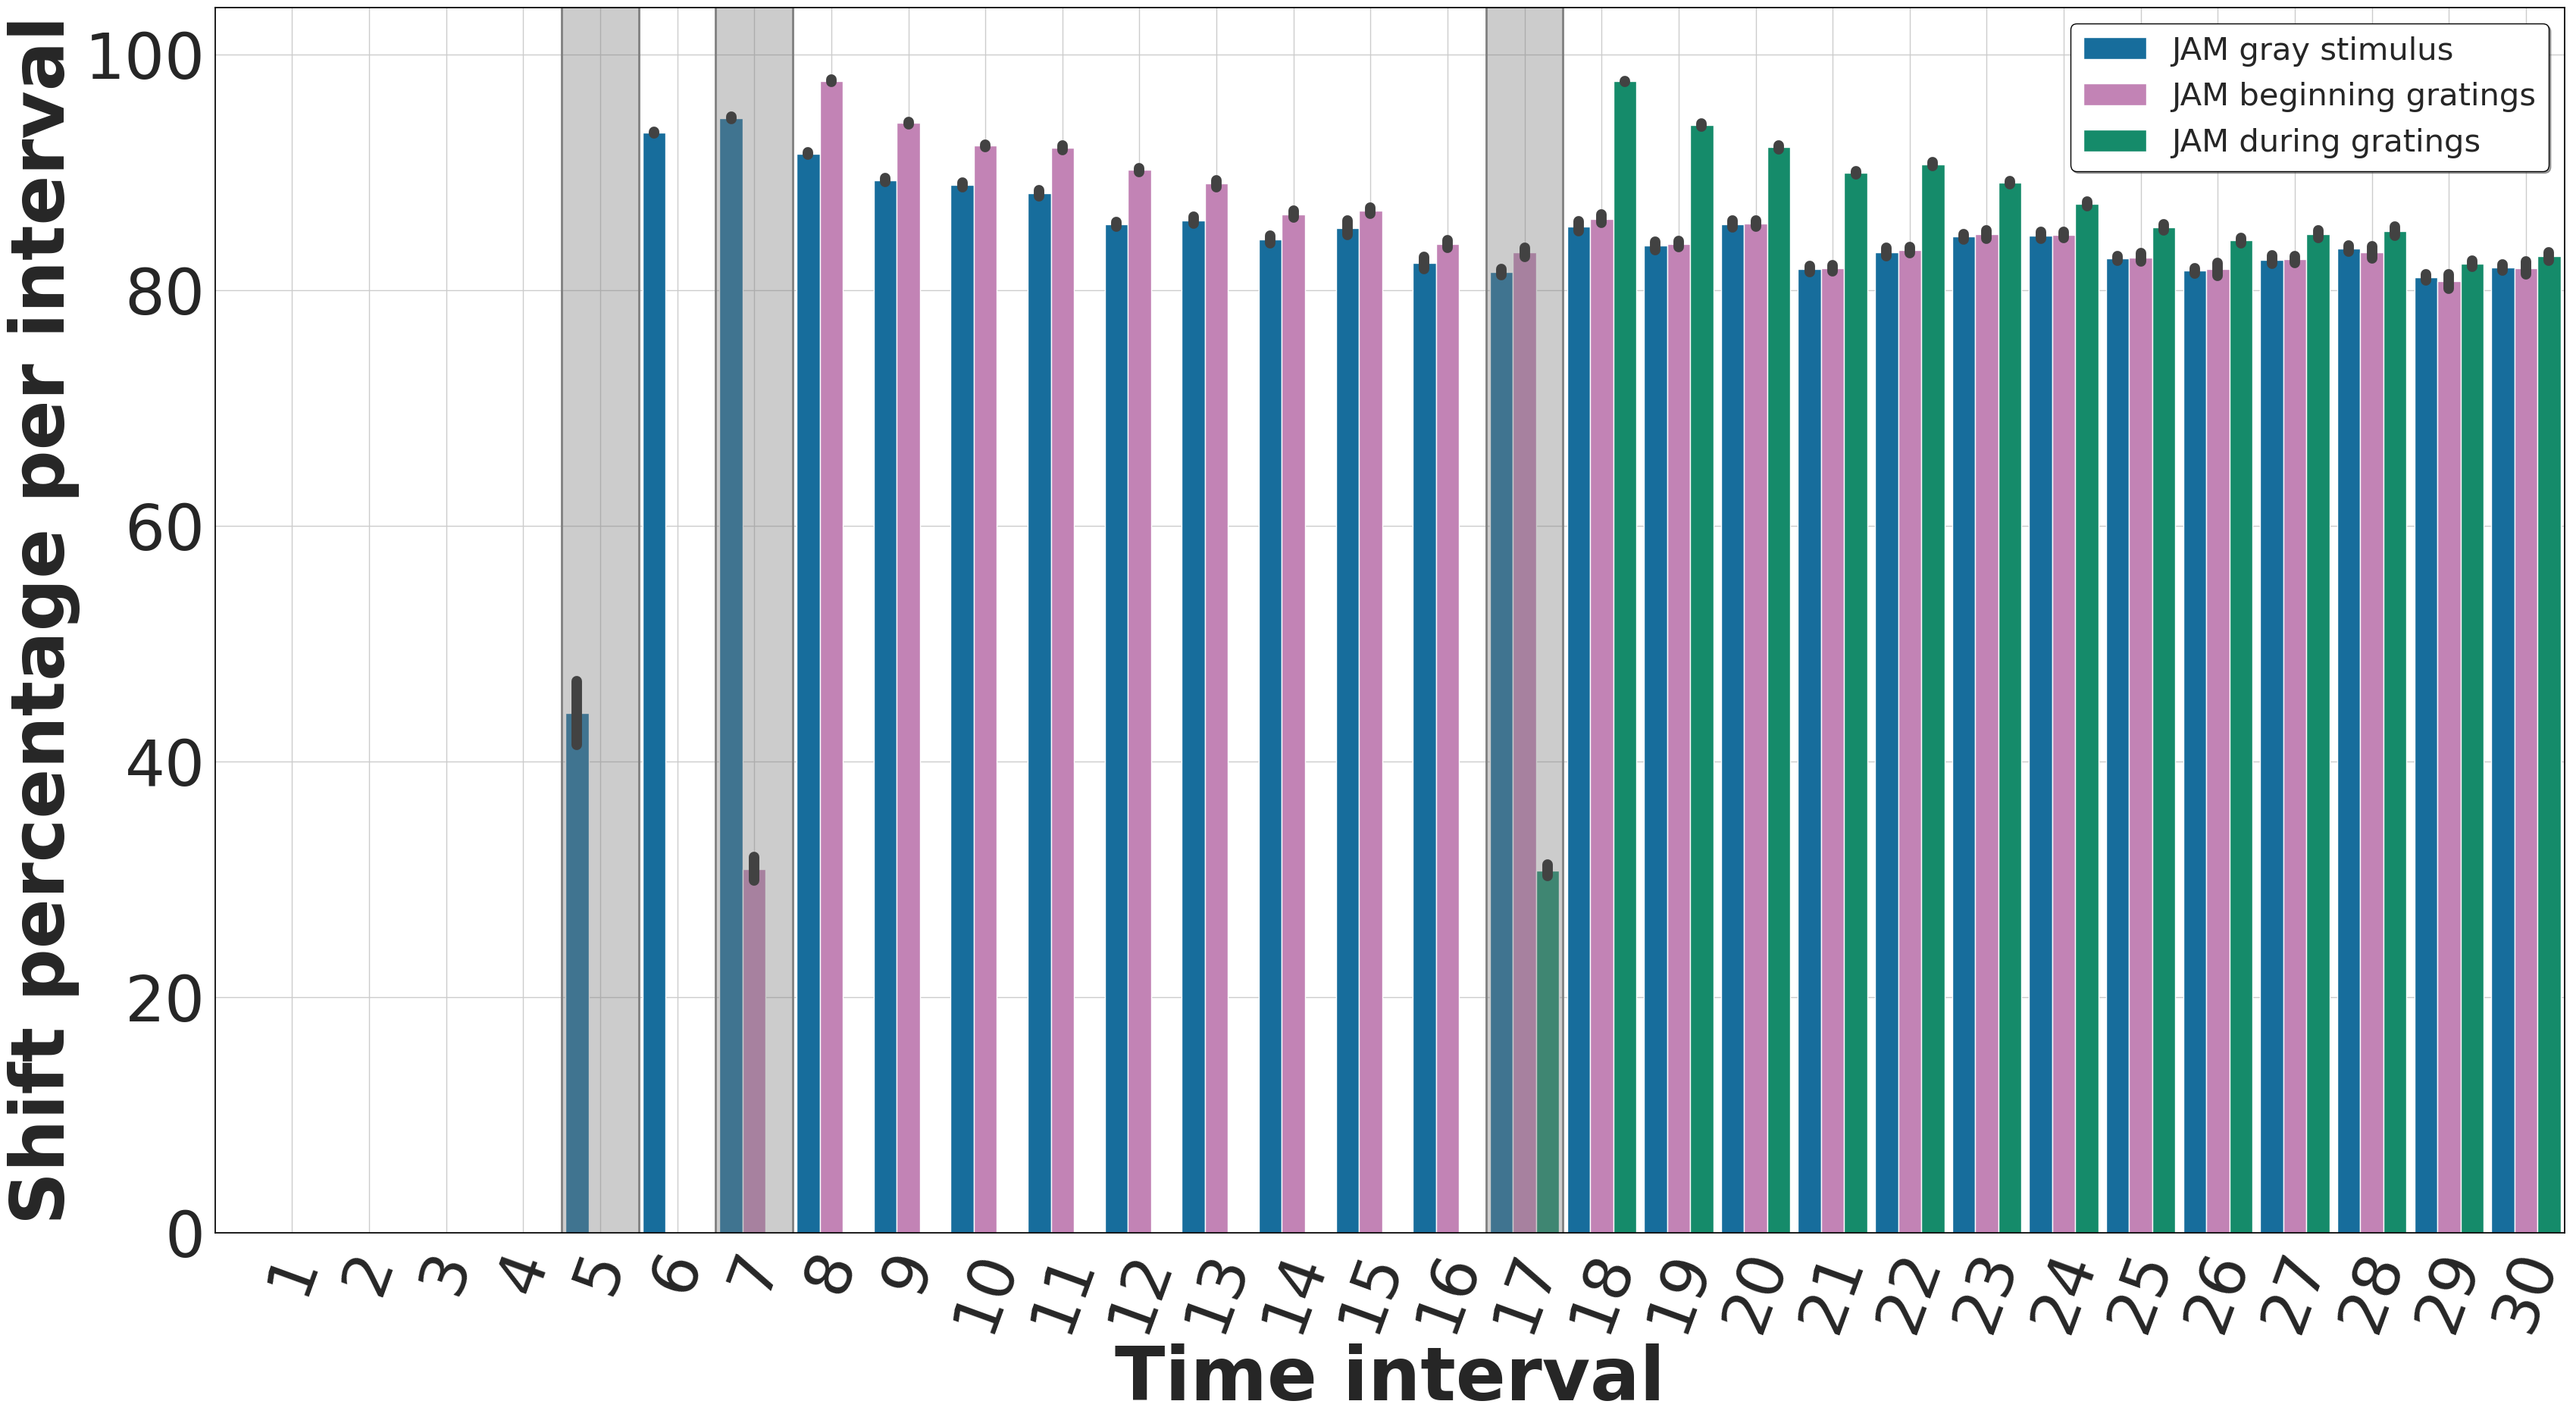

In [ ]:
combination_percentage_shift_per_instant(df_stimulus,df_stimulus_2,df_stimulus_3, "gratings")